# Decision Tree

In [1]:
# Data manipulation libraries.
import numpy as np
import pandas as pd

# Data visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Data modeling libraries.
from sklearn import tree

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100
pd.options.display.max_columns = None

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

## 1 Introduction

### 1.1 Usecase

#### Problem Statement

![Axis-parallel Decision boundaries](images/0_emp_att_dps.png)

- There are large number of data-points that needs to be grouped into chunks.
- Because this is a Supervised Learning technique, these groups have predefined class-labels.
- Data-points are **not linearly separable** (as seen in the above scatter plot).
- Simple Logistic Regression model cannot be used since data-points are not linearly separable.
- Data-points can to be classified into two or more class-labels. A **Multi-class classification** problem.

##### Why not Logistic Regression?

- Polynomial features can be created to fit a non-linear separator, but it increases model **complexity** and may **overfit**.
- Multi-class classification (one-vs-rest) creates multiple models (one for each class label), thus increasing **Training cost**.

##### Why not KNN?

KNN can we used to solve above problem statement but it is computationally expensive (since KNN is a Lazy Learner).

#### Use case: Employee Attrition

Dataset containing below information about employees:

  1. `age` - Age of Employee
  2. `ot_hrs`- Daily overtime in hours.

Predict employee attrition.

In [3]:
emp_df = pd.read_csv("data/employee_attrition.csv")

display(emp_df.sample(3, random_state=rng))
row_count, col_count = emp_df.shape
print(f"Dataset contains {row_count} rows and {col_count} columns.")

,age,ot_hrs,attrition
45,22.4,1.1,0
6,46.1,1.5,0
53,35.1,3.0,0


Dataset contains 70 rows and 3 columns.


In [4]:
emp_df["attrition"].value_counts()

attrition
0    42
1    28
Name: count, dtype: int64

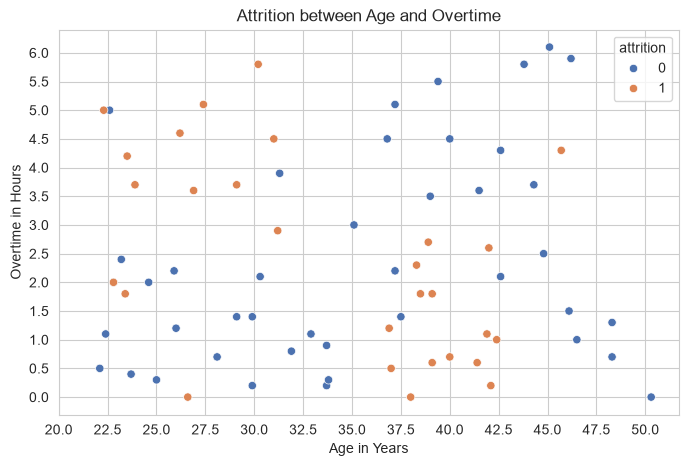

In [5]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=emp_df, x="age", y="ot_hrs", hue="attrition")
plt.title("Attrition between Age and Overtime")
plt.xlabel("Age in Years")
plt.ylabel("Overtime in Hours")
plt.xticks(ticks=np.arange(20, 51.5, 2.5))
plt.yticks(ticks=np.arange(0, 6.5, 0.5))

# plt.savefig("images/0_emp_att_dps.png", bbox_inches="tight")
plt.show()

#### Solution Approach

- We cannot use a simple Linear separator, as there are no linear relationship between each feature and target variable.
- Segregate data-points into **Homogeneous subspace**.

##### What is a Homogeneous subspace?

A Homogeneous subspace is a collection of data-points belonging to same class-label.

![Axis-parallel Decision boundaries](images/1_emp_att_apdb.png)

- These data-points can be divided into chunks or smaller groups using Tree based models.
- Tree based models can create chunks using axis-parallel decision boundaries as shown in above image.
- Tree based models create chunks by dividing datasets using:
  - One feature at a time.
  - One threshold at a time for each feature.
- Axis-parallel decision boundaries (black lines) are trying to group data-points into Homogeneous subspace.

### 1.2 Geometric Intuition

#### Decision

Decision is the split strategy applied on data-points using some threshold value.

#### Outcome of Decision process

- Decisions are applied on data-points using **features** to create **splits** or partitions.
- Value of a chosen feature at which the split occurs is called as **Threshold**.
- Decisions are taken such that the splitting of data-points results in a **Homogeneous subspace**. 
- For example if a decision is made as: `Age <= 35`
  - Selected feature is `Age`
  - Threshold value chose is `35`
- These splits can be represented using **Tree structure**.
- This process is repeated using different features and threshold values until all the nodes  
  towards the end of the tree contains data-points belonging to only one class-label.

#### Decision Tree

![Sample Decision Tree](images/2_emp_att_dt.png)

#### Structure of a Decision Tree

- Decision Tree is made up of Nodes.
- Decision Tree starts as a single node called **root node** before splitting based on a threshold.
- Decision Tree splits into branches based on some decision process.
- Goal of Decision Tree is that the split should result in a **Homogeneous node**.
- Decision Tree ends at one or more Homogeneous **Leaf nodes**.
- Nodes in between root and leaf are called decision nodes or internal nodes or intermediate nodes.

#### How prediction works?

- Given a test data-point start traversing the Decision tree from root node.
- Based on the feature selected and threshold set at the intermediate nodes, move left or right.
- Keep traversing until you reach a leaf node.
- Test data-point is predicted as belonging to:
  - CASE #1 Node is Homogeneous: The class-label of the leaf node it landed at.
  - CASE #2 Node is not Homogeneous: The class-label with the majority vote.

### 1.3 Decision Tree

#### When to choose Decision Trees?

- Non linearly separable decision boundary.
- Multi-class classification problem.

#### Properties

- Decision Tree supports both **Classification and Regression** problem types.
- Most popular implementation of Decision Trees is **CART** (Classification and Regression Tree).
- Some older versions of Decision Tree implementations are: ID3, C4.5

#### Advantages

- Unique advantage of Decision Tree is its **interpretability**.
- Decision Trees can handle **Multi-class classification** using single model.
- Decision trees can capture **complex nonlinear relationships** in the data.

#### Disadvantages

- Decision Trees can create only Axis-aligned or Axis-parallel Decision boundaries.
- Decision tree cannot create a simple Linear Separator (perfect diagonal line) instead results in a "staircase" decision boundary.

## 2 Algorithmic Components

### 2.1 Role of ML

#### Need for an ML Model

- Role of ML in Decision Tree is to **analyze the quality of a split**.
- Among infinitely possible splits (features and threshold combinations) we need the optimal splits.

#### Role of ML in Decision Trees

An ML model analyzes the quality of a split by answering below two questions:

- Which **dimension to choose for splitting** data-points among all available features.
- At what **threshold to make a split** after choosing an optimal feature.

#### Components of a ML Algorithm

1. Mapping Function: Function that maps input data-points to output predictions.
2. Loss Function: Function that evaluates the mapping function.
3. Optimization: Minimizes the loss function.

### 2.2 Mapping Function

#### Step Function

A simple step function can act as a mapping function in Decision Trees.

#### Examples

##### Example #1

Step Function:

$$
\large
\begin{aligned}
f(x) = 
\begin{cases}
\;1  & \text{when}\; x \ge 5 \\[10pt]
\;-1 & \text{when}\; x \lt 5
\end{cases}
\end{aligned}
$$

In [6]:
# Generate sample data.
x = np.arange(-5, 16, 0.1)
y = np.where(x >= 5, 1.0, -1.0)
# x, y

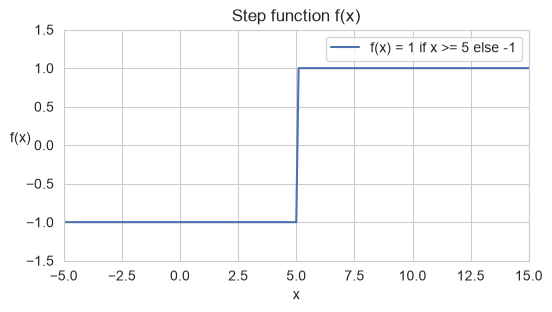

In [7]:
plt.figure(figsize=(6, 3))

sns.lineplot(x=x, y=y, label="f(x) = 1 if x >= 5 else -1")
plt.title("Step function f(x)")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)
plt.xlim(-5, 15)
plt.ylim(-1.5, 1.5)

plt.show()

### 2.3 Loss Function

#### Pure vs Impure Node

A node is considered as,

- Pure node (or homogeneous) if all of the data-points belong to a single class-label.
- Impure node (or heterogeneous) if at least one of data-point belongs to a different class-label.
- By default Decision Tree prioritizes purity of leaf nodes over impure leaf nodes.

#### Impurity vs Confidence

Confidence of predictions are inversely related to impurity:

- Higher the impurity lower the confidence in prediction.
- Lower the impurity higher the confidence in prediction.

#### Example

For example, out of 100 data-points, if a Leaf Node has:

- `[98 +ve,  2 -ve]` class-labels, it is considered as Impure node and will have high confidence in prediction.
- `[60 +ve, 40 -ve]` class-labels, it is considered as Impure node and will have low confidence in prediction.
- `[50 +ve, 50 -ve]` class-labels, it is considered as most impure node with lowest confidence in prediction.

#### Need for Loss function

- We need a mechanism to quantify the outcome of a decision process (Decision Tree) as a whole.
- Decision Tree is made up of nodes, hence we need to measure how Homogeneous (or pure) a particular node is.
- In other words, we need a Loss function that can:
  - **quantify the impurity of each Node**.
  - **quantify the quality of a split**.
- An ML model will decide what kind of a split will minimize the impurity at each step of decision process.

### 2.4 Optimization

#### Need for Optimization

- Optimization is needed to **improve Homogeneity** of a Node.
- In other words, there is a need to increase or **maximize purity** of a Node.
- To convert maximization problem into minimization problem, **reduce entropy** of a Node.

#### Entropy of Node

- Entropy of a single node

#### Entropy of Split

- Weighted average of entropy of both the nodes split from its parent node.

## 3 Measure of Uncertainty

### 3.1 Entropy

#### Definition

- Entropy measures the amount of randomness or disorder in a set of data.
- Entropy is the **measure of impurity** or uncertainty of a Node.

#### Formula

$$
\large
\text{Entropy}\;=\;H(S)\;=\;-\sum_{i\,=\;1}^c\,p_i\,\log_2({p_i})
$$

Where,

- $S$ - Subset of dataset in current node.
- $H(S)$ - Entropy of current subset in node
- $c$ - Total number of classes in the dataset
- $p$ - The probability of $i^\text{th}$ class

#### Properties

$$
\large
\uparrow\text{Entropy}\;\;=\;\;\uparrow\text{Impurity}
$$
- A perfectly **pure node** will have an **entropy** value **zero**.
- A perfectly **impure node** will have an **entropy** value **one**.
- For a node, entropy values range between $[0,\,1]$.
- **ID3** (Iterative Dichotomiser 3) implementation of Decision Tree **uses Entropy**.

#### Code

In [8]:
def entropy(cl_counts: list):
    """
    Function to calculate Entropy of a Node.
    """
    tot_count: int = sum(cl_counts)
    impurity: list[float] = []
    for cl_count in cl_counts:
        p_i: float = cl_count / tot_count
        loss = 0 if p_i == 0 else p_i * np.log2(p_i)
        impurity.append(loss)

    entropy = -sum(impurity) + 0  # Add zero to avoid -0 (Negative zero)

    return entropy.round(6).item()

#### Examples

##### Example #1: Perfectly pure node

In [9]:
entropy([100, 0])

0.0

##### Example #2: Perfectly impure node

In [10]:
entropy([50, 50])

1.0

##### Example #3: Nearly pure node

In [11]:
entropy([1, 99])

0.080793

##### Example #4: Nearly impure node

In [12]:
entropy([60, 40])

0.970951

##### More Examples

Calculate Entropy for below Decision Tree.

![Sample Decision Tree](images/3_emp_att_dt_entropy.png)

In [13]:
print(entropy([42, 28]))
print(entropy([30, 27]))
print(entropy([12, 1]))
print(entropy([26, 15]))
print(entropy([4, 12]))
print(entropy([21, 5]))
print(entropy([5, 10]))
print(entropy([0, 12]))
print(entropy([4, 0]))

0.970951
0.998001
0.391244
0.947435
0.811278
0.706274
0.918296
0.0
0.0


### 3.2 Information Gain

#### Definition

Reduction in Entropy is defined as Information Gain (IG).

IG can be calculated as **difference** between the **entropy of parent node** and **aggregated entropy of child nodes**.

$$
\large
\text{Information Gain}\;=\;\text{Entropy}_{\text{parent}}\;-\;\overline{\text{Entropy}}_{\text{split}}
$$

Where,

- $\text{Entropy}_{\text{parent}}$ - Entropy of parent node
- $\overline{\text{Entropy}}_{\text{split}}$ - Aggregated entropy of a split

#### Equation

Information Gain of a split based on some attribute $A$ using a subset $S$ from dataset $D$:

$$
\large
\text{Gain}(S,\,A)\;=\;H(S)\;-\;\sum_{i\,=\,1}^b\,\frac{\vert{S_i}\vert}{\vert{S}\vert}\,H(S_i)
$$

Where,

- $H(S)$ - Entropy of Parent node containing subset $S$ (before split).
- $b$ - Total number of branches.
- $\vert{S_i}\vert$ - Total number of data-points in $i^\text{th}$ branch or child-node.
- $\vert{S}\vert$ - Total number of data-points in subset $S$ (parent node).
- $H(S_i)$ - Entropy of $i^\text{th}$ branch or child-node.

#### How to calculate Information Gain?

- **STEP #1**: Calculate Entropy of Parent Node.
- **STEP #2**: Calculate Entropy of each child node after split.
- **STEP #3**: Entropies of child nodes are aggregated using **weighted average** of their entropies.
- **STEP #4**: Difference between entropy of Parent Node and aggregated entropy is the Information Gain.

#### Properties

- In a Decision Tree, optimal splits are selected based on Information Gain.
- Goal of Optimization is to pick a feature and threshold that results in highest Information Gain.
- Higher the Information Gain the better.
- ID3 implementation of Decision Tree leverages Entropy and Information Gain.

#### Code

In [14]:
def information_gain(parent: list, branches: list[list]):
    """
    Function to calculate Information Gain.
    """
    # Calculate Entropy of parent.
    h_parent = entropy(parent)
    s_tot = sum(parent)

    # Calculate weighted average of split Entropies.
    h_split = 0
    for branch in branches:
        # Calculate Entropy of child.
        h_child = entropy(branch)
        si_tot = sum(branch)
        h_split += si_tot / s_tot * h_child

    # Calculate information gain.
    info_gain = h_parent - h_split

    return h_parent, h_split, info_gain

#### Examples

##### Example #1

In [15]:
hp, hs, ig = information_gain(
    parent=[4, 11],
    branches=[
        [3, 3],  # Left split
        [1, 8],  # Right split
    ],
)
print("Entropy of parent:", round(hp, 6))
print("Entropy of split:", round(hs, 6))
print("Information Gain:", round(ig, 6))

Entropy of parent: 0.836641
Entropy of split: 0.701955
Information Gain: 0.134686


#### Stopping Criteria

When the Information Gain is Zero it can act as stopping criteria for splitting a node.

##### Example #1

In [16]:
hp, hs, ig = information_gain(
    parent=[1, 9],
    branches=[
        [0, 8],  # Left split
        [1, 0],  # Right split
    ],
)
print("Entropy of parent:", round(hp, 6))
print("Entropy of split:", round(hs, 6))
print("Information Gain:", round(ig, 6))

Entropy of parent: 0.468996
Entropy of split: 0.0
Information Gain: 0.468996


## 4 Measure of Heterogeneity

### 4.1 Gini Impurity

#### Definition

- Gini measures the likelihood that a randomly chosen element from a dataset would be incorrectly labeled if it were randomly classified according to the distribution of labels in that node.
- Gini is the **measures of impurity** or heterogeneity of a Node.

#### Formula

$$
\large
\text{Gini}\;=\;G(S)\;=\;1\,-\,\sum_{i\,=\;1}^c\,p_i^2
$$

or,

$$
\large
G(S)\;=\;\sum_{i\,=\;1}^c\,p_i\,(1 - p_i)
$$

Where,

- $S$ - Subset of dataset in current node.
- $G(S)$ - Gini Impurity of current subset in node.
- $c$ - Total number of classes in the dataset
- $p$ - The probability of $i^\text{th}$ class

#### Properties

- A perfectly **pure node** will have an **Gini Impurity** value **zero**.
- A perfectly **impure node** will have an **Gini Impurity** value **0.5**.
- For a Node, Gini Impurity range between $[0,\,0.5]$.
- **CART** (Classification and Regression Trees) implementation of Decision Tree **uses Gini Impurity**.
- Entropy is more computationally expensive compared to Gini Impurity because of its `log` operation.

#### Code

In [17]:
def gini_impurity(splits: list):
    """
    Function to calculate Gini Impurity using Formula #2.
    """
    probs = np.asarray(splits) / np.sum(splits)
    gi = 0
    for p_i in probs.tolist():
        gi += p_i * (1 - p_i)

    return round(gi, 3)

#### Examples

##### Example #1: Perfectly pure node

In [18]:
gini_impurity([0, 100])

0.0

##### Example #2: Perfectly impure node

In [19]:
gini_impurity([50, 50])

0.5

##### Example #3: Nearly pure node

In [20]:
gini_impurity([5, 95])

0.095

##### Example #4: Nearly impure node

In [21]:
gini_impurity([60, 40])

0.48

##### More Examples

Calculate Gini-Impurity for below Decision Tree.

![Sample Decision Tree](images/4_emp_att_dt_gini.png)

In [22]:
print(gini_impurity([42, 28]))
print(gini_impurity([30, 27]))
print(gini_impurity([12, 1]))
print(gini_impurity([26, 15]))
print(gini_impurity([4, 12]))
print(gini_impurity([21, 5]))
print(gini_impurity([5, 10]))
print(gini_impurity([0, 12]))
print(gini_impurity([4, 0]))

0.48
0.499
0.142
0.464
0.375
0.311
0.444
0.0
0.0


### 4.2 Gini Gain

#### Definition

Reduction in Gini Impurity is defined as Gini Gain.

Gini Gain can be calculated as **difference** between **Gini Impurity of parent node** and **aggregated Gini Impurity of child nodes**.

$$
\large
\text{Gini Gain}\;=\;\text{Gini}_{\text{parent}}\;-\;\overline{\text{Gini}}_{\text{split}}
$$

Where,

- $\text{Gini}_{\text{parent}}$ - Gini Impurity of parent node
- $\overline{\text{Gini}}_{\text{split}}$ - Aggregated Gini Impurity of a split

#### Equation

Gini Gain of a split based on some attribute $A$ using a subset $S$ from dataset $D$:

$$
\newcommand{\G}{\text{Gini}}
\large
\text{Gini Gain}(S,\,A)\;=\;\G(S)\;-\;\sum_{i\,=\,1}^b\,\frac{\vert{S_i}\vert}{\vert{S}\vert}\,\G(S_i)
$$

Where,

- $\text{Gini}(S)$ - Gini Impurity of Parent node containing subset $S$ (before split).
- $b$ - Total number of branches.
- $\vert{S_i}\vert$ - Total number of data-points in $i^\text{th}$ branch or child-node.
- $\vert{S}\vert$ - Total number of data-points in subset $S$ (parent node).
- $\text{Gini}(S_i)$ - Gini Impurity of $i^\text{th}$ branch or child-node.

#### How to calculate Gini Gain?

- **STEP #1**: Calculate Gini Impurity of Parent Node.
- **STEP #2**: Calculate Gini Impurity of each child node after split.
- **STEP #3**: Ginis of child nodes are aggregated using **weighted average** of their Gini impurities.
- **STEP #4**: Difference between Gini Impurity of Parent Node and aggregated Gini Impurity is the Gini Gain.

#### Properties

- In a Decision Tree, optimal splits are selected based on Gini Gain.
- Goal of Optimization is to pick a feature and threshold that results in highest Gini Gain.
- Higher the Gini Gain the better.
- CART implementation of Decision Tree leverages Gini-Impurity and Gini-Gain.

#### Code

In [23]:
def gini_gain(parent: list, branches: list[list]):
    """
    Function to calculate Gini Gain.
    """
    # Calculate Gini-Impurity of parent.
    g_parent = gini_impurity(parent)
    s_tot = sum(parent)

    # Calculate weighted average of split Ginies.
    g_split = 0
    for branch in branches:
        # Calculate Gini-Impurity of child.
        g_child = gini_impurity(branch)
        si_tot = sum(branch)
        g_split += si_tot / s_tot * g_child

    # Calculate Gini-Gain.
    gini_gain = g_parent - g_split

    return g_parent, g_split, gini_gain

#### Examples

##### Example #1

In [24]:
gp, gs, gg = gini_gain(
    parent=[4, 11],
    branches=[
        [3, 3],  # Left split
        [1, 8],  # Right split
    ],
)
print("Gini Impurity of parent:", round(gp, 6))
print("Gini Impurity of split:", round(gs, 6))
print("Gini Gain after split:", round(gg, 6))

Gini Impurity of parent: 0.391
Gini Impurity of split: 0.3188
Gini Gain after split: 0.0722


#### Stopping Criteria

When the Gini Gain is Zero it can act as stopping criteria for splitting a node.

##### Example #1

In [25]:
gp, gs, gg = gini_gain(
    parent=[1, 9],
    branches=[
        [0, 8],  # Left split
        [1, 0],  # Right split
    ],
)
print("Gini Impurity of parent:", round(gp, 6))
print("Gini Impurity of split:", round(gs, 6))
print("Gini Gain after split:", round(gg, 6))

Gini Impurity of parent: 0.18
Gini Impurity of split: 0.0
Gini Gain after split: 0.18
